In [362]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, chisquare, kstest, expon, uniform

# Simulation and estimation in a Markov model of breast cancer

# Part 1: A discrete-time model

## Task 1

In [363]:
def sim_liftime_women(n, P):
    death_state = 4
    life_times = []
    local = []

    for _ in range(n):
        state = 0
        t = 0

        had_local = False
        while state != death_state:
            if state in [1,3]:
                had_local = True
            
            state = np.random.choice(np.arange(5), p = P[state])

            t += 1

        life_times.append(t)
        local.append(had_local)
    
    return np.array(life_times), local


In [364]:
np.random.seed(42)
n = 1000
P  = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])

life_times1, local = sim_liftime_women(n,P)
np.mean(life_times1), np.sum(local)/n

(np.float64(265.035), np.float64(0.712))

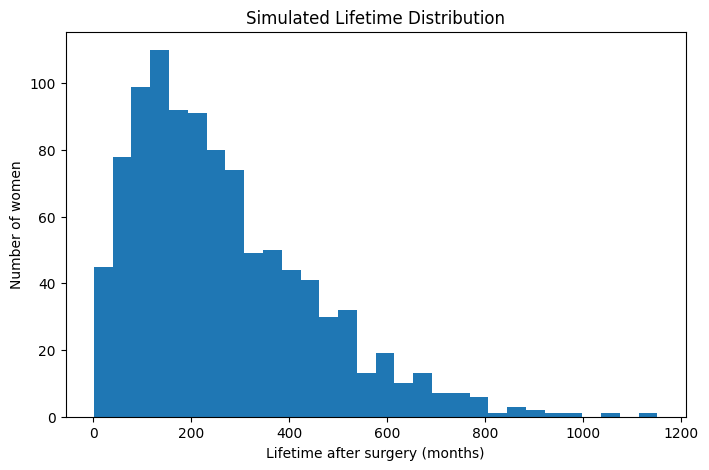

In [365]:
# Histogram
plt.figure(figsize=(8, 5))
plt.hist(life_times1, bins=30)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Simulated Lifetime Distribution")
plt.show()

## Task 2

In [366]:

def simulate_women(n,P, max_t=1200):

    n_states = 5
    death_state = n_states - 1

    lifetimes = []
    had_local = np.zeros(n, dtype=bool)
    had_local_12 = np.zeros(n, dtype=bool)

    counts = np.zeros((max_t + 1, n_states), dtype=int)

    states = np.zeros(n, dtype=int)
    alive = np.ones(n, dtype=bool)

    counts[0, 0] = n

    for t in range(1, max_t + 1):

        for i in np.where(alive)[0]:

            # transition first
            new_state = np.random.choice(
                n_states,
                p=P[states[i]]
            )

            states[i] = new_state

            # record local recurrence AFTER transition
            if new_state in [1, 3]:
                had_local[i] = True

                if t <= 12:              
                    had_local_12[i] = True

            # check death
            if new_state == death_state:
                alive[i] = False
                lifetimes.append(t)

        # store distribution
        counts[t] = np.bincount(states, minlength=n_states)

        # early stopping
        if not alive.any():
            counts[t:] = counts[t]
            break


    return np.array(lifetimes), had_local, counts, had_local_12

In [367]:
np.random.seed(42)
n = 1000
P  = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])

life_times, had_local, counts, had_local_12= simulate_women(n, P, max_t=1400)
np.mean(life_times), np.sum(had_local)/n

(np.float64(263.974), np.float64(0.707))

In [368]:
emp_state_120 = counts[120,:]

In [369]:
p0 = np.array([1, 0, 0, 0, 0])
n = 1000
times = [120]  # months

print("\nAnalytical state distributions:")
for t in times:
    Pt = np.linalg.matrix_power(P, t)
    pt_120 = (p0 @ Pt)*n

    print(f"\nt = {t} months")
    print("Theorical state distribution")
    print(f"{pt_120}")



Analytical state distributions:

t = 120 months
Theorical state distribution
[359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]


In [370]:
_, p_value_chi = chisquare(f_obs=emp_state_120, f_exp=pt_120)
print(f"Results of chi square test {p_value_chi}")

Results of chi square test 0.513404950761478


## Task 3

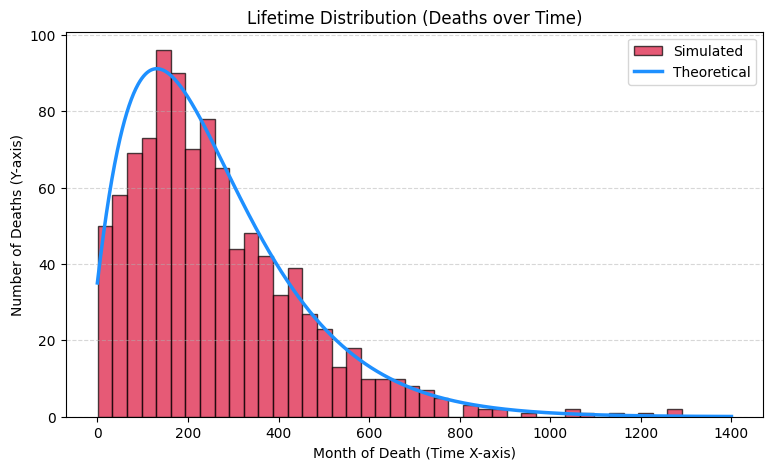

In [371]:
#Theoretical lifetime distribution
Pi= np.array([1000, 0,0,0])
Ps = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000],
    [0.0000, 0.9860, 0.0050, 0.0040],
    [0.0000, 0.0000, 0.9920, 0.0030],
    [0.0000, 0.0000, 0.0000, 0.9910]
])
ps= np.array([0.0010, 0.0050, 0.0050, 0.0090])

max_t = len(counts[:,0])


def prop_mass_T(t, Pi, Ps, ps):
    Ps_t = np.linalg.matrix_power(Ps, t)
    return Pi@ Ps_t @ps

theo_mass = []
for t in range(max_t):
    theo_mass.append(prop_mass_T(t, Pi, Ps, ps))

theo_mass = np.array(theo_mass)
plt.figure(figsize=(9, 5))
plt.hist(life_times, bins=40, color='crimson', edgecolor='black', alpha=0.7, label='Simulated')

bin_width = max_t / 40  
plt.plot(range(max_t), theo_mass * bin_width, color='dodgerblue', linewidth=2.5, label='Theoretical')

plt.title("Lifetime Distribution (Deaths over Time)")
plt.xlabel("Month of Death (Time X-axis)")
plt.ylabel("Number of Deaths (Y-axis)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Task 4 

In [409]:
accepted = []
n_women = 1000

while len(accepted) < n_women:
    life_times, _, _, had_local_12 = simulate_women(1, P, max_t=1200)
    death_women = life_times[0]

    if death_women >= 12 and had_local_12[0]:
        accepted.append(death_women)
    
estiamte = np.mean(accepted)
estiamte


IndexError: index 0 is out of bounds for axis 0 with size 0

In [406]:
life_times, _, counts, had_local_12 = simulate_women(1, P, max_t=1200)

In [407]:
life_times, had_local_12

(array([532]), array([False]))